# Model Evaluation

Evaluate pre-trained models.

### 1. Setup

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import time
import pandas as pd

# Modules
from utils.data_loader import get_dataloaders, load_adjacency_matrix
from models.STGCN import STGCN_Model
from models.GCNLSTM import GCNLSTM
from models.baseline import NaiveBaseline, HistoricalAverage
from models.DCRNN import DCRNNModel  

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


### 2. Data Loading

In [21]:
RETRAIN_STGCN = False
RETRAIN_GCNLSTM = False 
RETRAIN_DCRNN = False 

BATCH_SIZE = 32
NUM_NODES = 150
IN_FEATURES = 1
HISTORICAL_STEPS = 12
PRED_STEPS = 3
EVAL_MASK_THRESHOLD = 10.0

adj_matrix = load_adjacency_matrix('data/adj_mat_volume.pkl').to(device)
print(f"Loaded Adjacency Matrix")

# Process adj matrix
norm_adj_matrix = adj_matrix.clone()
idx = torch.arange(norm_adj_matrix.size(0), device=norm_adj_matrix.device)
norm_adj_matrix[idx, idx] = 1.0
degree = norm_adj_matrix.sum(dim=1, keepdim=True)
degree = torch.where(degree == 0, torch.ones_like(degree), degree)
norm_adj_matrix = norm_adj_matrix / degree

train_loader, val_loader, test_loader, data_mean, data_std = get_dataloaders(
    csv_path='data/sensor_volume_150.csv', 
    seq_len=HISTORICAL_STEPS, 
    pre_len=PRED_STEPS, 
    batch_size=BATCH_SIZE
)
print("DataLoaders initialized")

Loaded Adjacency Matrix
DataLoaders initialized


### 3. Setup Models
Load checkpoints or train models.

In [22]:
gcn_lstm_ckpt_scaler_mean = None
gcn_lstm_ckpt_scaler_std = None


# Baseline setup
print("\nInitializing Baselines")
baseline_model = NaiveBaseline(pred_steps=PRED_STEPS).to(device)
raw_df = pd.read_csv('data/sensor_volume_150.csv')
ha_model = HistoricalAverage(raw_data=raw_df.values.astype(np.float32), 
                             seq_len=HISTORICAL_STEPS, pre_len=PRED_STEPS)
print("Baselines initialized")


# STGCN
def train_stgcn(model, train_loader, val_loader, save_path='best_stgcn.pt', epochs=50, lr=0.005, weight_decay=1e-4, patience=10, retrain=False):
    history_path = save_path.replace('.pt', '_history.pt')

    if os.path.exists(save_path) and not retrain:
        try:
            ckpt = torch.load(save_path, map_location=device)
            state_dict = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
            model.load_state_dict(state_dict)
            print(f"Loaded STGCN")
            history = torch.load(history_path) if os.path.exists(history_path) else {'train': [], 'val': []}
            return model, history
        except Exception as e:
            print(f"STGCN load failed. Retraining...")
            
    print(f"\nTraining STGCN")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    criterion = torch.nn.MSELoss()
    
    best_val_loss, patience_counter = float('inf'), 0
    best_state = model.state_dict().copy()
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # Train
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            preds = model(batch_X, norm_adj_matrix)
            loss = criterion(preds, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        
        # Eval
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                preds = model(batch_X, norm_adj_matrix)
                loss = criterion(preds, batch_y)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        if avg_val_loss < best_val_loss:
            best_val_loss, patience_counter = avg_val_loss, 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1
            
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            
        if patience_counter >= patience:
            print(f"Early stop epoch {epoch+1}")
            break
            
    print(f"STGCN training done. Val Loss: {best_val_loss:.4f}")
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), save_path)
    history = {'train': train_losses, 'val': val_losses}
    torch.save(history, history_path)
    return model, history

print("\nInitializing STGCN")
stgcn_model = STGCN_Model(num_nodes=NUM_NODES, in_features=IN_FEATURES, historical_steps=HISTORICAL_STEPS, pred_steps=PRED_STEPS).to(device)
stgcn_model, stgcn_hist = train_stgcn(stgcn_model, train_loader, val_loader, save_path='best_stgcn.pt', epochs=50, lr=0.005, weight_decay=1e-4, patience=10, retrain=RETRAIN_STGCN)
stgcn_model.eval()


# GCN-LSTM
def train_gcnlstm(model, train_loader, val_loader, save_path='gcn_lstm_checkpoint.pth', epochs=100, lr=1e-3, weight_decay=1e-4, patience=15, retrain=False):
    global gcn_lstm_ckpt_scaler_mean, gcn_lstm_ckpt_scaler_std
    history_path = save_path.replace('.pth', '_history.pt')

    if os.path.exists(save_path) and not retrain:
        try:
            ckpt = torch.load(save_path, map_location=device)
            state_dict = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
            model.load_state_dict(state_dict)

            if isinstance(ckpt, dict) and 'scaler_mean' in ckpt and 'scaler_std' in ckpt:
                gcn_lstm_ckpt_scaler_mean = torch.as_tensor(ckpt['scaler_mean'], dtype=torch.float32, device=device)
                gcn_lstm_ckpt_scaler_std = torch.as_tensor(ckpt['scaler_std'], dtype=torch.float32, device=device)
                gcn_lstm_ckpt_scaler_std = torch.where(gcn_lstm_ckpt_scaler_std == 0, torch.ones_like(gcn_lstm_ckpt_scaler_std), gcn_lstm_ckpt_scaler_std)

            print(f"Loaded GCNLSTM")
            history = torch.load(history_path) if os.path.exists(history_path) else {'train': [], 'val': []}
            return model, history
        except Exception as e:
            print(f"GCNLSTM load failed. Retraining...")
            
    print(f"\nTraining GCNLSTM")
    gcn_lstm_ckpt_scaler_mean, gcn_lstm_ckpt_scaler_std = None, None

    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    criterion = torch.nn.MSELoss()
    
    best_val_loss, patience_counter = float('inf'), 0
    best_state = model.state_dict().copy()
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # Train
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            batch_X = batch_X.squeeze(1).transpose(1, 2)
            preds = model(batch_X, norm_adj_matrix).transpose(1, 2)
            loss = criterion(preds, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        
        # Eval
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                batch_X = batch_X.squeeze(1).transpose(1, 2)
                preds = model(batch_X, norm_adj_matrix).transpose(1, 2)
                loss = criterion(preds, batch_y)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        if avg_val_loss < best_val_loss:
            best_val_loss, patience_counter = avg_val_loss, 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1
            
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            
        if patience_counter >= patience:
            print(f"Early stop epoch {epoch+1}")
            break
            
    print(f"GCNLSTM training done. Val Loss: {best_val_loss:.4f}")
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), save_path)
    history = {'train': train_losses, 'val': val_losses}
    torch.save(history, history_path)
    return model, history

print("\nInitializing GCN-LSTM")
gcn_lstm_model = GCNLSTM(num_nodes=NUM_NODES, in_features=IN_FEATURES, gcn_hidden=32, lstm_hidden=64, output_len=PRED_STEPS).to(device)
gcn_lstm_model, lstm_hist = train_gcnlstm(gcn_lstm_model, train_loader, val_loader, save_path='gcn_lstm_checkpoint.pth', epochs=100, lr=1e-3, weight_decay=1e-4, patience=15, retrain=RETRAIN_GCNLSTM)
gcn_lstm_model.eval()


# DCRNN
def train_dcrnn(model, train_loader, val_loader, save_path='dcrnn_checkpoint.pth', epochs=50, lr=0.001, weight_decay=0.0, patience=10, retrain=False):
    history_path = save_path.replace('.pth', '_history.pt')

    if os.path.exists(save_path) and not retrain:
        try:
            ckpt = torch.load(save_path, map_location=device)
            state_dict = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
            model.load_state_dict(state_dict)
            print(f"Loaded DCRNN")
            history = torch.load(history_path) if os.path.exists(history_path) else {'train': [], 'val': []}
            return model, history
        except Exception as e:
            print(f"DCRNN load failed. Retraining...")
            
    print(f"\nTraining DCRNN")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    criterion = torch.nn.MSELoss()
    
    best_val_loss, patience_counter = float('inf'), 0
    best_state = model.state_dict().copy()
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # Train
        model.train()
        train_loss = 0.0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            batch_X = batch_X.permute(0, 3, 2, 1)
            preds = model(batch_X, T_f=norm_adj_matrix, T_b=norm_adj_matrix.T)
            preds = preds.squeeze(-1).transpose(1, 2)
            loss = criterion(preds, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        
        # Eval
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                batch_X = batch_X.permute(0, 3, 2, 1)
                preds = model(batch_X, T_f=norm_adj_matrix, T_b=norm_adj_matrix.T)
                preds = preds.squeeze(-1).transpose(1, 2)
                loss = criterion(preds, batch_y)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        
        if avg_val_loss < best_val_loss:
            best_val_loss, patience_counter = avg_val_loss, 0
            best_state = model.state_dict().copy()
        else:
            patience_counter += 1
            
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
            
        if patience_counter >= patience:
            print(f"Early stop epoch {epoch+1}")
            break
            
    print(f"DCRNN training done. Val Loss: {best_val_loss:.4f}")
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), save_path)
    history = {'train': train_losses, 'val': val_losses}
    torch.save(history, history_path)
    return model, history

print("\nInitializing DCRNN")
dcrnn_model = DCRNNModel(num_nodes=NUM_NODES, in_features=IN_FEATURES, hidden_dim=64, out_features=1, output_seq_len=PRED_STEPS, num_layers=2, K=2, use_attention=False).to(device)
dcrnn_model, dcrnn_hist = train_dcrnn(dcrnn_model, train_loader, val_loader, save_path='dcrnn_checkpoint.pth', epochs=50, lr=0.001, weight_decay=0.0, patience=10, retrain=RETRAIN_DCRNN)
dcrnn_model.eval()


Initializing Baselines
Baselines initialized

Initializing STGCN
Loaded STGCN

Initializing GCN-LSTM


C:\Users\hataj\AppData\Local\Temp\ipykernel_11572\1209237231.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(save_path, map_location=device)
C:\Users\

Loaded GCNLSTM

Initializing DCRNN
Loaded DCRNN


C:\Users\hataj\AppData\Local\Temp\ipykernel_11572\1209237231.py:198: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(save_path, map_location=device)


DCRNNModel(
  (learned_adj): LearnedAdjacency()
  (encoder): DCGRUEncoder(
    (cells): ModuleList(
      (0): DCGRUCell(
        (gate_conv): DiffusionConv(
          (linear): Linear(in_features=325, out_features=128, bias=True)
        )
        (cand_conv): DiffusionConv(
          (linear): Linear(in_features=325, out_features=64, bias=True)
        )
        (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
      (1): DCGRUCell(
        (gate_conv): DiffusionConv(
          (linear): Linear(in_features=640, out_features=128, bias=True)
        )
        (cand_conv): DiffusionConv(
          (linear): Linear(in_features=640, out_features=64, bias=True)
        )
        (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
    )
  )
  (decoder): DCGRUDecoder(
    (cells): ModuleList(
      (0): DCGRUCell(
        (gate_conv): DiffusionConv(
          (linear): Linear(in_features=325, out_features=128, bias=True)
        )
        (cand_conv): Diff

### 4. Evaluation Pipeline

In [23]:
def evaluate_model(model, loader, name, format_type='stgcn', pred_slice=3):
    all_preds = []
    all_targets = []
    gcn_uses_ckpt_scaler = (
        format_type == 'gcnlstm'
        and gcn_lstm_ckpt_scaler_mean is not None
        and gcn_lstm_ckpt_scaler_std is not None
    )
    
    batch_start_idx = 0
    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)
            
            if format_type == 'stgcn':
                preds = model(batch_X, norm_adj_matrix)
                all_preds.append(preds.cpu().numpy())
                all_targets.append(batch_y.cpu().numpy())
                
            elif format_type == 'ha':
                batch_size = batch_X.shape[0]
                preds = model.predict(batch_start_idx, batch_size)
                batch_start_idx += batch_size
                all_preds.append(preds)
                all_targets.append(batch_y.cpu().numpy())

            elif format_type == 'gcnlstm':
                if gcn_uses_ckpt_scaler:
                    # Reverse normalize
                    batch_X_raw = batch_X * data_std + data_mean
                    mean_x = gcn_lstm_ckpt_scaler_mean.view(1, 1, NUM_NODES, 1)
                    std_x = gcn_lstm_ckpt_scaler_std.view(1, 1, NUM_NODES, 1)
                    batch_X_model = (batch_X_raw - mean_x) / std_x

                    batch_X_model = batch_X_model.squeeze(1).transpose(1, 2)
                    preds = model(batch_X_model, norm_adj_matrix)

                    preds_raw = preds * gcn_lstm_ckpt_scaler_std.view(1, 1, NUM_NODES) + gcn_lstm_ckpt_scaler_mean.view(1, 1, NUM_NODES)

                    targets_raw = batch_y * data_std + data_mean

                    all_preds.append(preds_raw.transpose(1, 2).cpu().numpy())
                    all_targets.append(targets_raw.cpu().numpy())
                else:
                    batch_X = batch_X.squeeze(1).transpose(1, 2)
                    preds = model(batch_X, norm_adj_matrix)
                    all_preds.append(preds.cpu().numpy())
                    all_targets.append(batch_y.cpu().numpy())
                
            elif format_type == 'dcrnn':
                # Reshape
                batch_X = batch_X.permute(0, 3, 2, 1)
                preds = model(batch_X, T_f=norm_adj_matrix, T_b=norm_adj_matrix.T)
                preds = preds.squeeze(-1).transpose(1, 2)
                all_preds.append(preds.cpu().numpy())
                all_targets.append(batch_y.cpu().numpy())

    # Concat
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    if all_preds.shape != all_targets.shape:
        if (
            all_preds.ndim == 3
            and all_targets.ndim == 3
            and all_preds.shape[1] == all_targets.shape[2]
            and all_preds.shape[2] == all_targets.shape[1]
        ):
            all_preds = np.transpose(all_preds, (0, 2, 1))
    
    # Restore scale
    targets_unnorm = (all_targets * data_std) + data_mean
    
    if gcn_uses_ckpt_scaler or format_type == 'ha':
        preds_unnorm = all_preds
    else:
        if all_preds.shape[-1] > pred_slice:
            all_preds = all_preds[..., :pred_slice]
        preds_unnorm = (all_preds * data_std) + data_mean
        
    if gcn_uses_ckpt_scaler:
        targets_unnorm = all_targets

    # Mask
    mask = targets_unnorm > EVAL_MASK_THRESHOLD
    if not np.any(mask):
        print(f"{name} Results")
        print("No valid targets.")
        return preds_unnorm, targets_unnorm

    mae = np.mean(np.abs(preds_unnorm[mask] - targets_unnorm[mask]))
    rmse = np.sqrt(np.mean(np.square(preds_unnorm[mask] - targets_unnorm[mask])))
    mape = np.mean(np.abs((preds_unnorm[mask] - targets_unnorm[mask]) / targets_unnorm[mask])) * 100

    print(f"{name} Results")
    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAPE: {mape:.3f}%")
    print("-" * 40)
    
    return preds_unnorm, targets_unnorm

### 5. Evaluate

In [24]:
# Naive Baseline
base_preds, trues = evaluate_model(baseline_model, test_loader, "Naive Baseline", format_type='stgcn')

# Historical Average Baseline
ha_preds, _ = evaluate_model(ha_model, test_loader, "Historical Average", format_type='ha')

# STGCN
stgcn_preds, _ = evaluate_model(stgcn_model, test_loader, "STGCN Model", format_type='stgcn')

# GCN-LSTM
lstm_preds, _ = evaluate_model(gcn_lstm_model, test_loader, "GCN-LSTM Model", format_type='gcnlstm')

# DCRNN
dcrnn_preds, _ = evaluate_model(dcrnn_model, test_loader, "DCRNN Model", format_type='dcrnn')

Naive Baseline Results
MAE:  878.999
RMSE: 1328.162
MAPE: 33.000%
----------------------------------------
Historical Average Results
MAE:  604.451
RMSE: 946.529
MAPE: 28.299%
----------------------------------------
STGCN Model Results
MAE:  483.880
RMSE: 712.311
MAPE: 18.726%
----------------------------------------
GCN-LSTM Model Results
MAE:  518.357
RMSE: 732.856
MAPE: 21.050%
----------------------------------------
DCRNN Model Results
MAE:  262.410
RMSE: 391.229
MAPE: 9.713%
----------------------------------------


### 6. Visualize

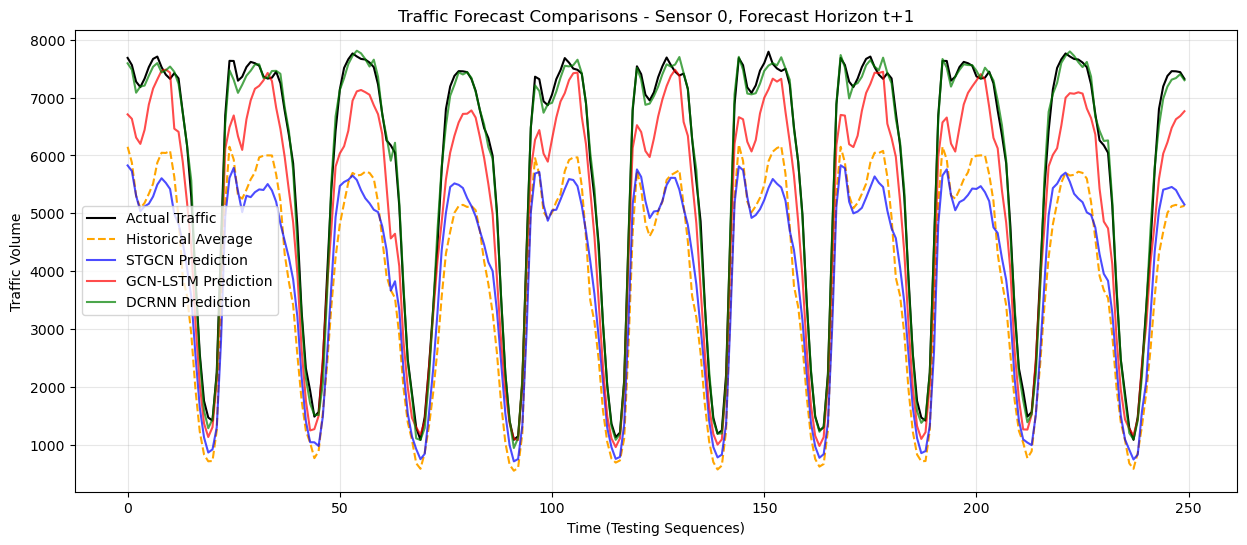

In [25]:
SENSOR = 0
TIMESTEP = 0 
PLT_LEN = 250

plt.figure(figsize=(15, 6))

plt.plot(trues[:PLT_LEN, SENSOR, TIMESTEP], label='Actual Traffic', color='black', linewidth=1.5)
plt.plot(ha_preds[:PLT_LEN, SENSOR, TIMESTEP], label='Historical Average', color='orange', linestyle='--')
plt.plot(stgcn_preds[:PLT_LEN, SENSOR, TIMESTEP], label='STGCN Prediction', color='blue', alpha=0.7)
plt.plot(lstm_preds[:PLT_LEN, SENSOR, TIMESTEP], label='GCN-LSTM Prediction', color='red', alpha=0.7)
plt.plot(dcrnn_preds[:PLT_LEN, SENSOR, TIMESTEP], label='DCRNN Prediction', color='green', alpha=0.7)

plt.title(f'Traffic Forecast Comparisons - Sensor {SENSOR}, Forecast Horizon t+{TIMESTEP+1}')
plt.xlabel('Time (Testing Sequences)')
plt.ylabel('Traffic Volume')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

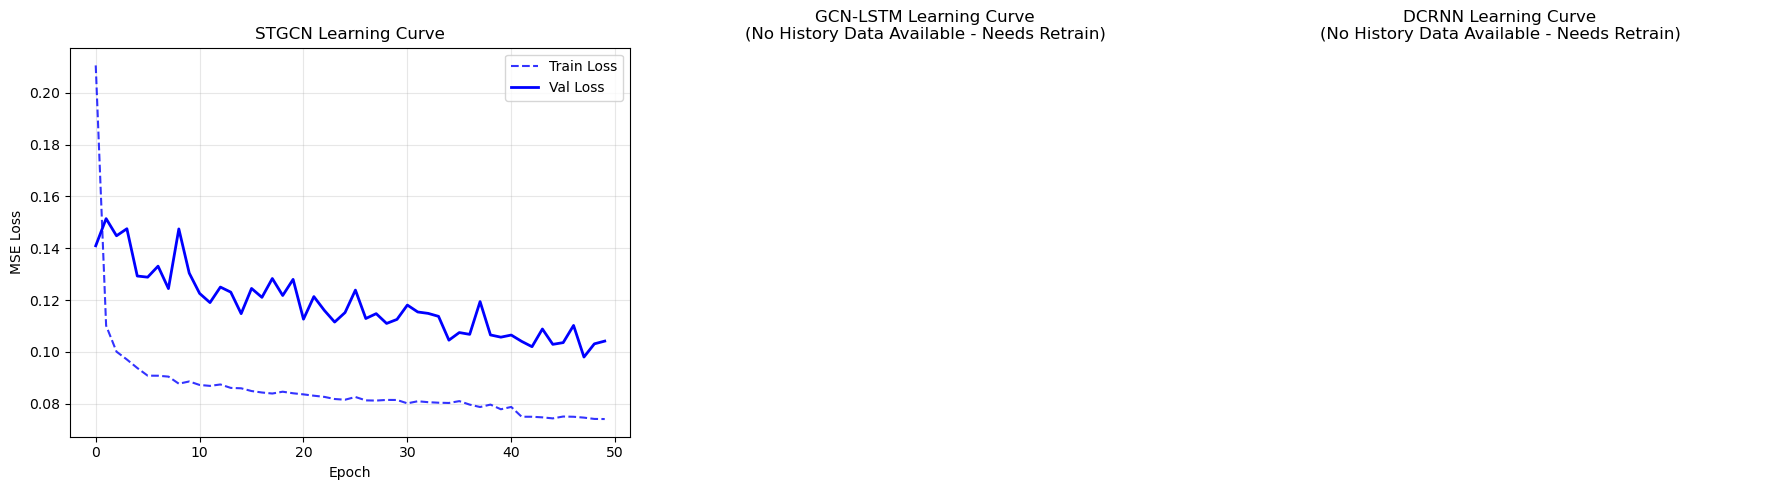

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_hist = [
    ('STGCN', stgcn_hist, 'blue'),
    ('GCN-LSTM', lstm_hist, 'red'),
    ('DCRNN', dcrnn_hist, 'green')
]

for ax, (name, hist, color) in zip(axes, models_hist):
    if hist and len(hist.get('train', [])) > 0:
        ax.plot(hist['train'], label='Train Loss', color=color, linestyle='--', alpha=0.8)
        ax.plot(hist['val'], label='Val Loss', color=color, linestyle='-', linewidth=2)
        ax.set_title(f'{name} Learning Curve')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('MSE Loss')
        ax.legend()
        ax.grid(True, alpha=0.3)
    else:
        ax.set_title(f'{name} Learning Curve\n(No History Data Available - Needs Retrain)')
        ax.axis('off')

plt.tight_layout()
plt.show()